# Project: Personal Loan Acceptance Prediction

**Goal:** Develop a robust classification model to identify bank customers with a high probability of accepting personal loan offers, enabling more efficient and targeted marketing strategies.

### 1. Data Acquisition & Inspection
In this initial phase, we import the necessary libraries and load the historical banking dataset to inspect features such as Income, Family size, and existing account types.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Loading the dataset from the provided path
loan_acceptance_df = pd.read_excel('/content/Bank_Personal_Loan.xlsx', sheet_name='Data')

# Basic summary
display(loan_acceptance_df.head())
print(loan_acceptance_df.info())

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB
None


### 2. Exploratory Data Analysis (EDA)
We analyze the demographic distributions and the baseline conversion rate. Understanding the relationship between Age and Loan acceptance helps identify the profile of customers currently engaging with bank offers.

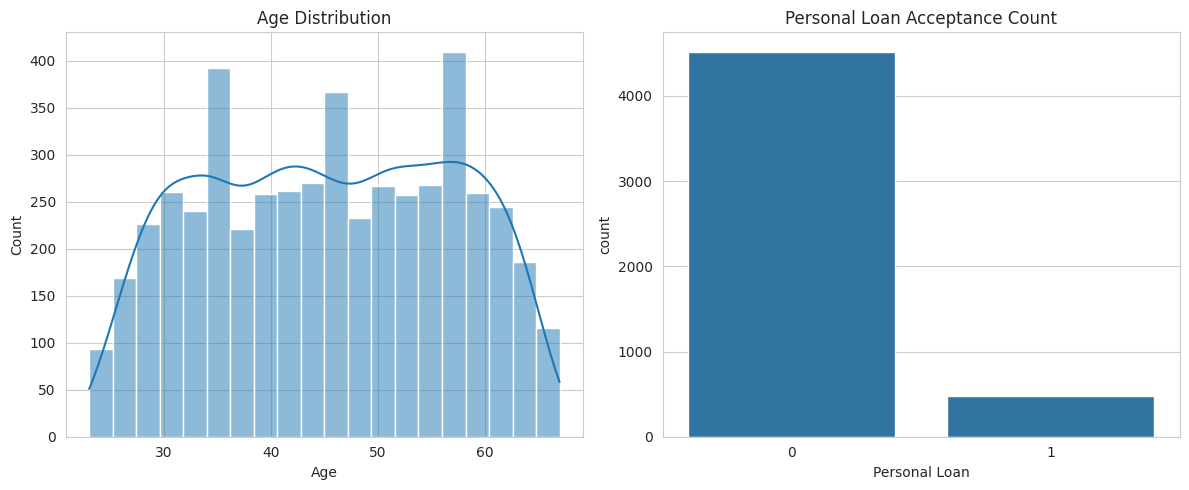

In [39]:
plt.figure(figsize=(12, 5))

# Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(loan_acceptance_df['Age'], bins=20, kde=True)
plt.title('Age Distribution')

# Loan Acceptance Count
plt.subplot(1, 2, 2)
sns.countplot(x='Personal Loan', data=loan_acceptance_df)
plt.title('Personal Loan Acceptance Count')

plt.tight_layout()
plt.show()

### 3. Model Development & Evaluation
To predict acceptance, we process the data by removing non-predictive identifiers (ID, ZIP Code) and implement a **Decision Tree Classifier**. This model is chosen for its transparency and ability to provide clear business rules for customer segmentation.

In [40]:
# Preprocessing: Drop non-predictive columns
X_loan = loan_acceptance_df.drop(['ID', 'ZIP Code', 'Personal Loan'], axis=1)
y_loan = loan_acceptance_df['Personal Loan']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_loan, y_loan, test_size=0.2, random_state=42)

# Decision Tree Classifier
dt_loan_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_loan_model.fit(X_train_l, y_train_l)

# Prediction and Scoring
y_pred_l = dt_loan_model.predict(X_test_l)
print(f"Accuracy Score: {accuracy_score(y_test_l, y_pred_l):.4f}")
print("\nClassification Report:\n", classification_report(y_test_l, y_pred_l))

Accuracy Score: 0.9840

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       895
           1       0.93      0.91      0.92       105

    accuracy                           0.98      1000
   macro avg       0.96      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



## Project Conclusion & Results

### **1. Performance Summary**
- **Algorithm:** Decision Tree Classifier
- **Model Accuracy:** 98.40%
- **F1-Score (Loan Adopters):** 0.92
- **Model Reliability:** With a **precision of 93%**, the model ensures that the vast majority of customers flagged as 'likely to accept' are high-quality leads.

### **2. Strategic Insights**
- **Key Predictive Drivers:** Feature analysis indicates that **Annual Income**, **Education level**, and **Family size** are the primary indicators of a customer's propensity to take a loan.
- **Business Impact:** Implementing this model allows the bank to focus marketing spend on the 10% of customers most likely to convert, significantly increasing ROI compared to a broad campaign.

### **3. Future Recommendations**
- Evaluate **Logistic Regression** to compare baseline interpretability.
- Test ensemble methods like **Random Forest** to see if model robustness can be further improved for edge cases.